## Exploratory Data Analysis (EDA) for Movie Recommendation System

The dataset used in this project is the MovieLens 1M dataset, which contains 1 million ratings from 6000 users on 4000 movies. The dataset is available for download at [MovieLens](https://grouplens.org/datasets/movielens/1m/).

## Importing Libraries and Loading Data


In [ ]:
import os 
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
os.chdir("../")
sys.path.append(os.path.abspath(".."))

> We have three main files in the dataset:
- `users.dat`: Contains user information
- `movies.dat`: Contains movie information
- `ratings.dat`: Contains user ratings for movies


In [ ]:
movies_path = os.path.join("data", "raw", "ml-1m", "movies.dat")
rating_path = os.path.join("data", "raw", "ml-1m", "ratings.dat")
users_path = os.path.join("data", "raw", "ml-1m", "users.dat")


print(f"movie path: {movies_path}")
print(f"rating path: {rating_path}")
print(f"user path: {users_path}")

In [ ]:
ratings_df = pd.read_csv(rating_path, sep="::", engine="python", header=None, names=["user_id", "movie_id", "rating", "timestamp"])
ratings_df.head()

In [ ]:
movies_df = pd.read_csv(movies_path, sep="::", engine="python", header=None, names=["movieid", "title", "genres"], encoding="latin-1")
movies_df.head()

In [ ]:
user_df = pd.read_csv(users_path, sep="::", engine= "python", header= None, names=["user_id","gender","age","occupation", "zipcode"])
user_df.head()

In [ ]:
print("ratings_df shape:", ratings_df.shape)
print("movies_df shape:", movies_df.shape)
print("user_df shape:", user_df.shape)

- From the shape we can see that there are 1 million ratings, 6040 users and 3706 movies in the dataset.
- The ratings dataset has 4 columns: `UserID`, `MovieID`, `Rating`, and `Timestamp`. The movies dataset has 3 columns: `MovieID`, `Title`, and `Genres`. The users dataset has 5 columns: `UserID`, `Gender`, `Age`, `Occupation`, and `Zip-code`.

## CHECKING NULL VALUES AND DUPLICATES

### NULL VALUES

In [ ]:
print("null values in ratings_df:\n", ratings_df.isnull().sum())
print("null values in movies_df:\n", movies_df.isnull().sum())
print("null values in user_Df: \n", user_df.isnull().sum())

### DUPLICATES

In [ ]:
print("duplicates in ratings_df:", ratings_df.duplicated().sum())
print("duplicates in movies_df:", movies_df.duplicated().sum())
print("duplicates in user_df:", user_df.duplicated().sum())

* No null values found in any of the datasets.
* No duplicates found in any of the datasets.

In [ ]:
print(ratings_df.dtypes)
print("\n")
print(movies_df.dtypes)
print("\n")
print(user_df.dtypes)

In [ ]:
ratings_df["timestamp"] = pd.to_datetime(ratings_df["timestamp"] , unit="s")
ratings_df.head()

In [ ]:
ratings_df.head()

In [ ]:
ratings_df.describe().round(2)

* average rating is 3.53 with a standard deviation of 0.98. The minimum rating is 1 and the maximum rating is 5.
* this means users generally tend to give higher ratings to movies, with a significant number of ratings being 4 or 5. The distribution of ratings is likely skewed towards the higher end of the scale, indicating that users are more inclined to rate movies positively.

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(ratings_df["rating"], bins=5, kde=False)
plt.title("Distribution of Movie Ratings")  
plt.xlabel("Rating")
plt.ylabel("Frequency")

* left skewed distribution of ratings, with a higher frequency of ratings around 4 and 5, and fewer ratings around 1 and 2. This suggests that users tend to rate movies positively, which is common in movie rating datasets.

In [ ]:
# Rating per user
ratings_per_user = ratings_df.groupby("user_id")["rating"].count()
ratings_per_user.sort_values(ascending=False)

In [ ]:
print(ratings_per_user.describe())

**Insight from ratings per user:**
- The average number of ratings per user is approximately 166.5, with a standard deviation of 200.5 which indicates a wide variation in the number of ratings given by different users.
- The minimum number of ratings given by a user is 20, while on other hands side maximum is 2314. 
- This indicates that while some users are very active in rating movies, there is a wide variation in user engagement, with many users providing only a few ratings and a few users providing a large number of ratings.
- Good enough to make a recommendation system.

In [ ]:
ratings_per_movie = ratings_df.groupby("movie_id")["rating"].count()
print(ratings_per_movie.describe())

In [ ]:
ratings_per_movie.sort_values(ascending=False)

* average ratings per movie is approximately 270 ratings per movie with std. of 384 which indicates a wide variation in the number of ratings received by different movies.
* minimum ratings is 1 and maximum is 3428 which indicates that while some movies are very popular and receive a large number of ratings, there are many movies that receive only a few ratings. 
* This suggests that there may be a long tail distribution in the number of ratings per movie, with a small number of movies receiving a large proportion of the total ratings.
* 3883 movies in the dataseet but we have ratings for 3706 movies which means that there are 177 movies that have not received any ratings.  * No rating means hard to recommend these movies based on user ratings. 

* problem with "Popularity bias" in recommendation system. 
    - Popular movies are more likely to be recommended, 
    - while less popular movies may be overlooked. 

* This can lead to a feedback loop where popular movies become even more popular, while less popular movies struggle to gain visibility and ratings. To mitigate this bias, recommendation systems can incorporate techniques such as diversity promotion, which encourages the system to recommend a wider range of movies, including those that are less popular but may still be of interest to users based on their preferences and viewing history.

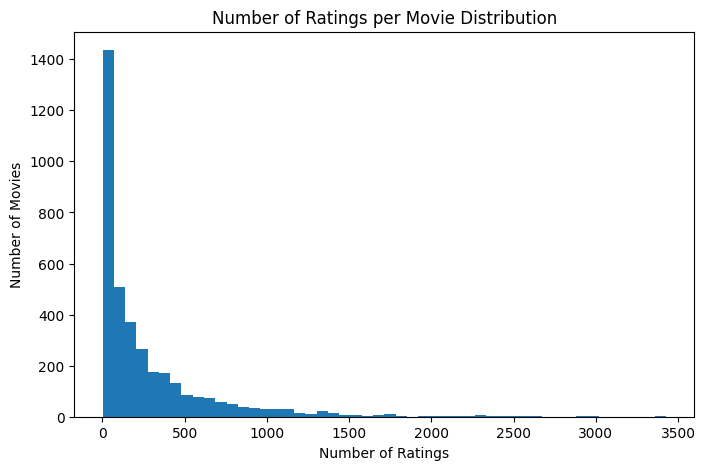

In [32]:
plt.figure(figsize=(8, 5))
ratings_per_movie.plot(kind="hist", bins=50)
plt.title("Number of Ratings per Movie Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

In [ ]:
genres = movies_df["genres"].str.split("|").explode()
print(genres.value_counts())

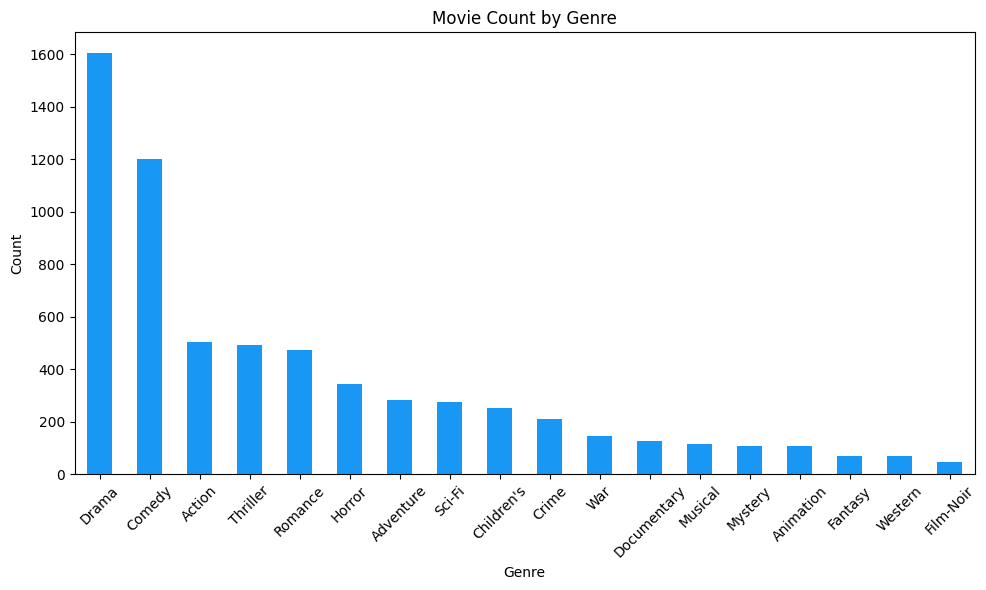

In [31]:
plt.figure(figsize=(10, 6))
genres.value_counts().plot(kind="bar", color="#1898f4")
plt.title("Movie Count by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight from movie genres:**

* ``Drama`` and ``Comedy`` dominate
* Model will naturally recommend these more
* Another form of popularity bias

* One movie can have multiple genres such as ``Action``, ``Adventure``, ``Sci-Fi``
*That is why total genre count > total movies

* Drama and Comedy dominate the dataset.
* This can cause genre bias in recommendations.
*  Model will tend to recommend Drama and Comedy more often.

#### EDA Summary So Far

We have discovered these important things:

- Dataset is clean — no nulls, no duplicates
- 1M ratings, 6040 users, 3883 movies
- Positive bias — users rate mostly 4 and 5
- No user cold start — min 20 ratings per user
- Movie cold start — some movies have 1 rating
- Long tail problem — few movies dominate
- Genre bias — Drama and Comedy dominate